#### Also known as Z - Score Normalization

In [28]:
import numpy as np
import pandas as pd 
from matplotlib import pyplot as plt 
import seaborn as sns

In [ ]:

df = pd.read_csv('Social_Network_Ads.csv')
df=df.iloc[:,2:]  # Removing strings 
df.sample(10)

,Age,EstimatedSalary,Purchased
338,38,55000,0
97,28,123000,1
339,39,122000,1
54,27,58000,0
38,26,72000,0
325,41,60000,0
307,47,113000,1
399,49,36000,1
185,31,66000,0
248,41,52000,0


<Axes: xlabel='Age', ylabel='EstimatedSalary'>

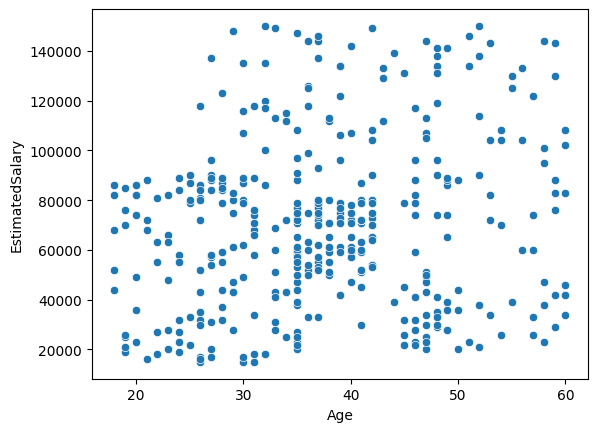

In [30]:
sns.scatterplot(x=df['Age'], y=df['EstimatedSalary'])

### Train Test Split 

In [31]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(df.drop('Purchased', axis=1), df['Purchased'], test_size=0.3, random_state=0)

X_train.shape, X_test.shape

((280, 2), (120, 2))

### StandardScaler

In [32]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()  # creating an object 

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
# but the above scaled would be in numpy arrays 

# Converting np arrays in the form of tables
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

np.round(X_train.describe(), 1)
np.round(X_train_scaled.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


### Effect of Scaling

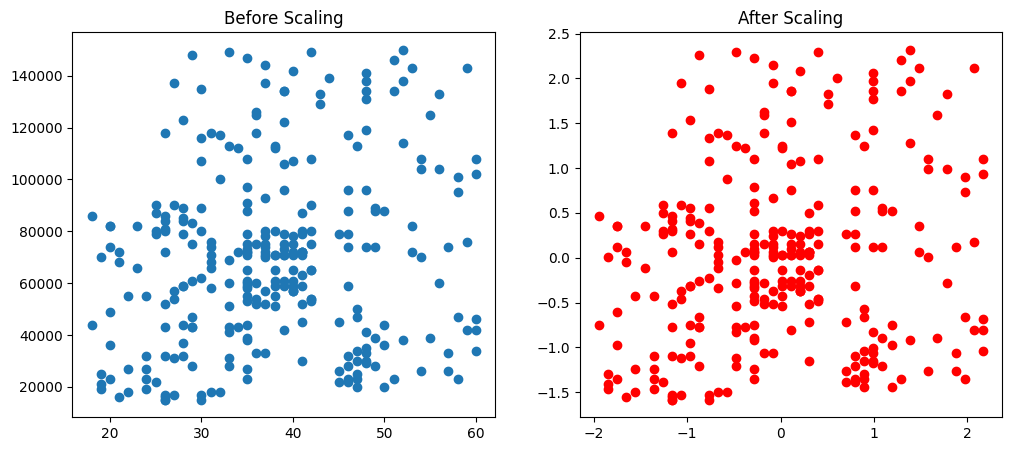

In [33]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")
plt.show()